In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the Northwind database
conn = sqlite3.connect("northwind.db")

# Display all tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


In [2]:
# Top 10 Best Selling Products

query = """
SELECT
    p.ProductName,
    SUM(od.Quantity) AS TotalSold
FROM Products p
JOIN "Order Details" od
ON p.ProductID = od.ProductID
GROUP BY p.ProductID, p.ProductName
ORDER BY TotalSold DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query, conn)

top_products

,ProductName,TotalSold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


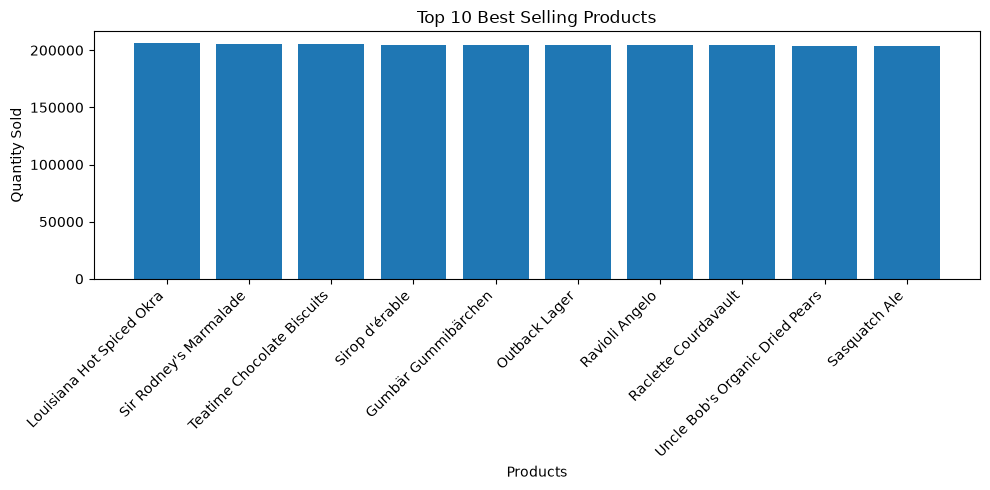

In [3]:
# Bar Chart - Top Selling Products

plt.figure(figsize=(10,5))
plt.bar(top_products["ProductName"], top_products["TotalSold"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Best Selling Products")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.show()

In [4]:
query = """
SELECT
    c.CompanyName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS TotalRevenue
FROM Customers c
JOIN Orders o ON c.CustomerID = o.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
GROUP BY c.CustomerID, c.CompanyName
ORDER BY TotalRevenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query, conn)
top_customers

,CompanyName,TotalRevenue
0,B's Beverages,6154115.34
1,Hungry Coyote Import Store,5698023.67
2,Rancho grande,5559110.08
3,Gourmet Lanchonetes,5552309.80
4,Ana Trujillo Emparedados y helados,5534356.65
5,Ricardo Adocicados,5524517.31
6,Folies gourmandes,5505502.85
7,Let's Stop N Shop,5462198.02
8,LILA-Supermercado,5437438.34
9,Princesa Isabel Vinhos,5436770.55


In [5]:
query = """
SELECT
    strftime('%Y-%m', o.OrderDate) AS Month,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Sales
FROM Orders o
JOIN "Order Details" od ON o.OrderID = od.OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql_query(query, conn)
monthly_sales

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51


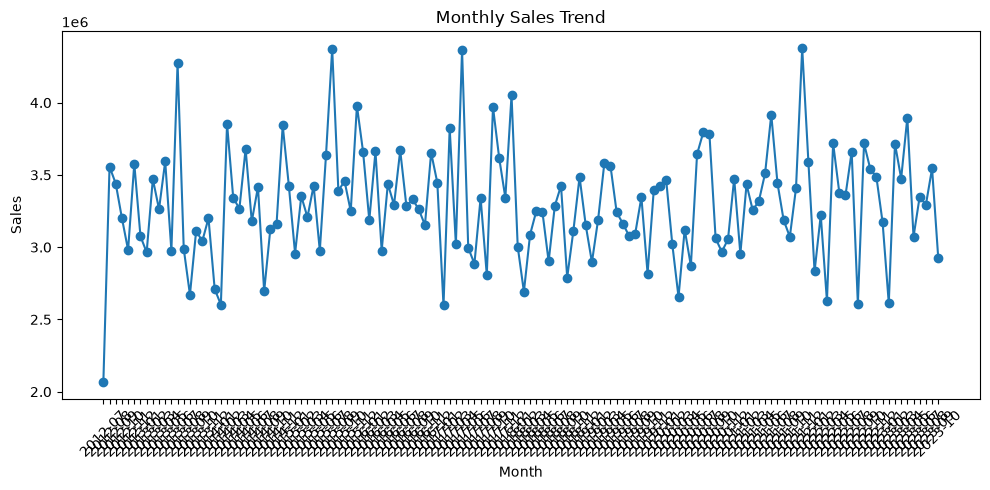

In [6]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["Month"], monthly_sales["Sales"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


In [7]:
query = """
SELECT
    c.CategoryName,
    SUM(od.Quantity) AS TotalSold
FROM Categories c
JOIN Products p ON c.CategoryID = p.CategoryID
JOIN "Order Details" od ON p.ProductID = od.ProductID
GROUP BY c.CategoryName
ORDER BY TotalSold DESC;
"""

category_sales = pd.read_sql_query(query, conn)
category_sales

,CategoryName,TotalSold
0,Confections,2628466
1,Beverages,2427361
2,Condiments,2420864
3,Seafood,2410782
4,Dairy Products,2020160
5,Grains/Cereals,1412853
6,Meat/Poultry,1207892
7,Produce,1010224


In [8]:
query = """
SELECT
    c.CompanyName,
    COUNT(o.OrderID) AS OrderCount
FROM Customers c
JOIN Orders o ON c.CustomerID = o.CustomerID
GROUP BY c.CustomerID, c.CompanyName
ORDER BY OrderCount DESC;
"""

customer_orders = pd.read_sql_query(query, conn)
customer_orders

,CompanyName,OrderCount
0,B's Beverages,210
1,LILA-Supermercado,203
2,Ricardo Adocicados,203
3,Gourmet Lanchonetes,202
4,Princesa Isabel Vinhos,200
...,...,...
88,Around the Horn,156
89,FISSA Fabrica Inter. Salchichas S.A.,155
90,Furia Bacalhau e Frutos do Mar,155
91,La corne d'abondance,155
